In [2]:
import geopandas as gpd
import pandas as pd
import numpy as np
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
flood_dir = Path("/Users/khuenguyen/Desktop/team-nuclear-family/raw_data/flood/")
print(list(flood_dir.glob("*.gpkg")))

[PosixPath('/Users/khuenguyen/Desktop/team-nuclear-family/raw_data/flood/flood_nevada.gpkg'), PosixPath('/Users/khuenguyen/Desktop/team-nuclear-family/raw_data/flood/flood_arizona.gpkg'), PosixPath('/Users/khuenguyen/Desktop/team-nuclear-family/raw_data/flood/flood_tennesse.gpkg'), PosixPath('/Users/khuenguyen/Desktop/team-nuclear-family/raw_data/flood/flood_georgia.gpkg'), PosixPath('/Users/khuenguyen/Desktop/team-nuclear-family/raw_data/flood/flood_utah.gpkg'), PosixPath('/Users/khuenguyen/Desktop/team-nuclear-family/raw_data/flood/flood_louisiana.gpkg'), PosixPath('/Users/khuenguyen/Desktop/team-nuclear-family/raw_data/flood/flood_illinois.gpkg'), PosixPath('/Users/khuenguyen/Desktop/team-nuclear-family/raw_data/flood/flood_district_of_columbia.gpkg'), PosixPath('/Users/khuenguyen/Desktop/team-nuclear-family/raw_data/flood/flood_wyoming.gpkg'), PosixPath('/Users/khuenguyen/Desktop/team-nuclear-family/raw_data/flood/flood_mississippi.gpkg'), PosixPath('/Users/khuenguyen/Desktop/team-

In [4]:
county = gpd.read_file("/Users/khuenguyen/Desktop/team-nuclear-family/raw_data/county_boundaries_2025/tl_2025_us_county.shp").to_crs(epsg = 5070)
county.head()

,STATEFP,COUNTYFP,COUNTYNS,GEOID,GEOIDFQ,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,CSAFP,CBSAFP,METDIVFP,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,40,075,01101825,40075,0500000US40075,Kiowa,Kiowa County,06,H1,G4020,None,None,None,A,2629039892,40296743,+34.9214893,-098.9816168,"POLYGON ((-267035.259 1343980.561, -266490.502..."
1,46,079,01265776,46079,0500000US46079,Lake,Lake County,06,H1,G4020,None,None,None,A,1457916151,31746795,+44.0284497,-097.1232229,"POLYGON ((-71100.31 2327435.998, -71100.293 23..."
2,37,033,01008542,37033,0500000US37033,Caswell,Caswell County,06,H1,G4020,None,None,None,A,1102042927,8293623,+36.3943252,-079.3396193,"POLYGON ((1489331.21 1620697.325, 1489336.836 ..."
3,48,377,01383974,48377,0500000US48377,Presidio,Presidio County,06,H1,G4020,None,None,None,A,9985057447,1773188,+30.0058912,-104.2616192,"POLYGON ((-857749.848 879396.771, -857744.209 ..."
4,39,057,01074041,39057,0500000US39057,Greene,Greene County,06,H1,G4020,212,19430,None,A,1071302625,6798109,+39.6874785,-083.8948943,"POLYGON ((1008169.795 1915287.022, 1008161.905..."


In [4]:
assert county["GEOID"].nunique() == len(county)

In [5]:
all_county_flood = []

for gpkg_path in sorted(flood_dir.glob("*.gpkg")):
    try:
        flood = gpd.read_file(gpkg_path).to_crs(epsg=5070)
        flood = flood.drop_duplicates(subset=["geometry"])  # fix duplicates
        flood["geometry"] = flood.geometry.buffer(0)        # fix invalid geometries
        
        overlap = gpd.overlay(county, flood, how="intersection", keep_geom_type=True)
        overlap["overlap_area"] = overlap.geometry.area
        overlap["is_sfha"] = overlap["SFHA_TF"] == "T"
        
        sfha = overlap.groupby("GEOID")["overlap_area"].apply(
            lambda x: x[overlap.loc[x.index, "is_sfha"]].sum()
        ).reset_index(name="sfha_area")
        
        all_county_flood.append(sfha)
        print(f"✓ {gpkg_path.name}")
        
    except Exception as e:
        print(f"✗ {gpkg_path.name} — {e}")
        continue

# Combine
flood_counties = pd.concat(all_county_flood, ignore_index=True)
flood_counties = flood_counties.groupby("GEOID")["sfha_area"].sum().reset_index()
flood_counties = flood_counties.merge(county[["GEOID", "NAMELSAD", "county_area"]], on="GEOID")
flood_counties["pct_sfha"] = flood_counties["sfha_area"] / flood_counties["county_area"]

✓ flood_alabama.gpkg
✓ flood_alaska.gpkg
✓ flood_american_samoa.gpkg
✓ flood_arizona.gpkg
✓ flood_arkansas.gpkg
✓ flood_california.gpkg
✓ flood_colorado.gpkg
✓ flood_connecticut.gpkg
✓ flood_delaware.gpkg
✓ flood_district_of_columbia.gpkg
✓ flood_florida.gpkg
✓ flood_georgia.gpkg
✓ flood_guam.gpkg
✓ flood_hawaii.gpkg
✓ flood_idaho.gpkg
✓ flood_illinois.gpkg
✓ flood_indiana.gpkg
✓ flood_iowa.gpkg
✓ flood_kansas.gpkg
✓ flood_kentucky.gpkg
✓ flood_louisiana.gpkg
✓ flood_maine.gpkg
✓ flood_mariana_islands.gpkg
✓ flood_maryland.gpkg
✓ flood_massachusetts.gpkg
✓ flood_michigan.gpkg
✓ flood_minnesota.gpkg
✓ flood_mississippi.gpkg
✓ flood_missouri.gpkg
✓ flood_montana.gpkg
✓ flood_nebraska.gpkg
✓ flood_nevada.gpkg
✓ flood_new_hampshire.gpkg
✓ flood_new_jersey.gpkg
✓ flood_new_mexico.gpkg
✓ flood_new_york.gpkg
✓ flood_north_carolina.gpkg
✓ flood_north_dakota.gpkg
✓ flood_ohio.gpkg
✓ flood_oklahoma.gpkg
✓ flood_oregon.gpkg
✓ flood_pensylvannia.gpkg
✓ flood_puerto_rico.gpkg
✓ flood_rhode_island.g

KeyError: "['county_area'] not in index"

In [6]:
county["county_area"] = county.area
flood_counties = flood_counties.merge(county[["GEOID", "NAMELSAD", "county_area"]], on="GEOID")
flood_counties["pct_sfha"] = flood_counties["sfha_area"] / flood_counties["county_area"]

In [7]:
flood_counties

,GEOID,sfha_area,NAMELSAD,county_area,pct_sfha
0,01001,2.351783e+08,Autauga County,1.565309e+09,0.150244
1,01003,1.109788e+09,Baldwin County,5.250612e+09,0.211364
2,01005,2.723647e+08,Barbour County,2.342684e+09,0.116262
3,01007,1.667939e+08,Bibb County,1.621761e+09,0.102847
4,01009,9.727207e+07,Blount County,1.685119e+09,0.057724
...,...,...,...,...,...
3155,72151,3.010548e+07,Yabucoa Municipio,2.155977e+08,0.139637
3156,72153,8.072733e+06,Yauco Municipio,1.770603e+08,0.045593
3157,78010,6.146456e+07,St. Croix Island,8.615598e+08,0.071341
3158,78020,1.968500e+07,St. John Island,2.376683e+08,0.082826


In [8]:
flood_counties[flood_counties["pct_sfha"] > 1]

,GEOID,sfha_area,NAMELSAD,county_area,pct_sfha


In [14]:
flood_counties = flood_counties.rename(columns = {"NAMELSAD": "county_name"})
assert flood_counties["GEOID"].nunique() == len(flood_counties)

### Key columns in `flood_counties`
- `GEOID`, `county_name`: county name and id
- `county_area`: area of county in $m^2$
- `sfha_area`: severa flood hazard area (sfha) of each county in $m^2$
- `pct_sfha`: perceentage of sfha in each county

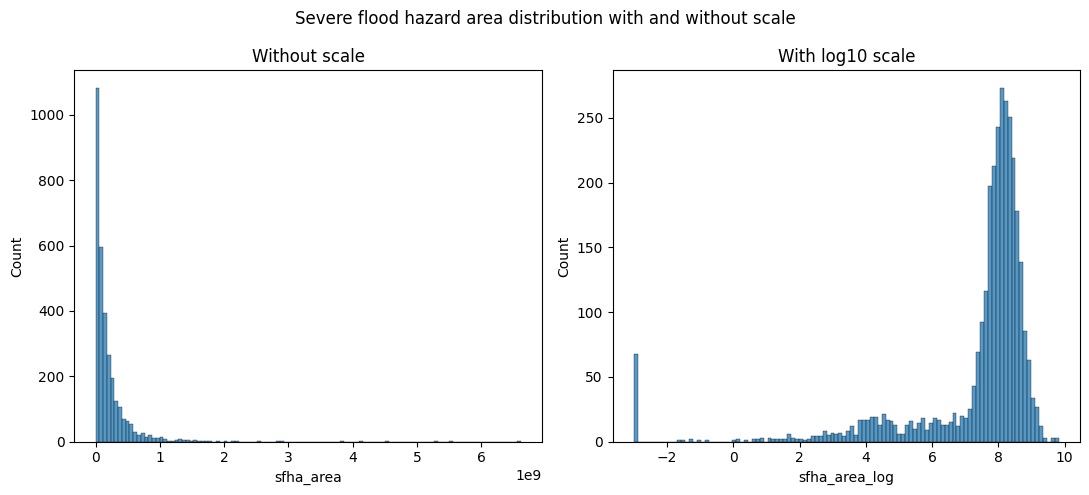

In [20]:
# add 0.001 to avoid zero division

flood_counties["sfha_area_log"] = np.log10(flood_counties["sfha_area"] + 0.001)

fig, ax = plt.subplots(1, 2, figsize = (11, 5))

sns.histplot(
    data = flood_counties, 
    x = "sfha_area", 
    ax = ax[0]
)

sns.histplot(
    data = flood_counties, 
    x = "sfha_area_log",
    ax = ax[1]
)

ax[0].set_title("Without scale")
ax[1].set_title("With log10 scale")

plt.suptitle("Severe flood hazard area distribution with and without scale")
plt.tight_layout()
plt.savefig("../results/sfha_area_distribution.png", bbox_inches = "tight")

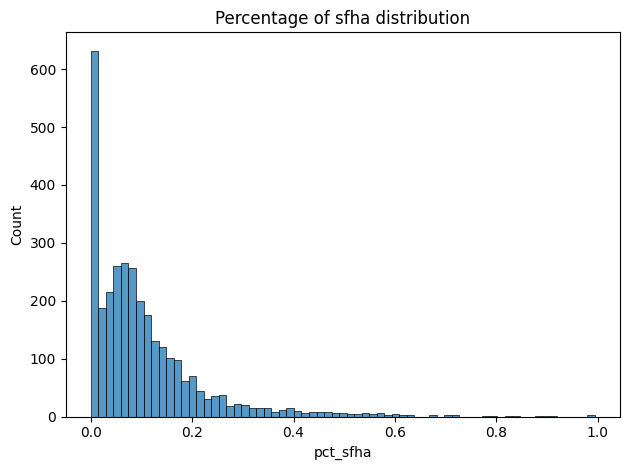

In [58]:
sns.histplot(
    data = flood_counties, 
    x = "pct_sfha"
)

plt.title("Percentage of sfha distribution")
plt.tight_layout()

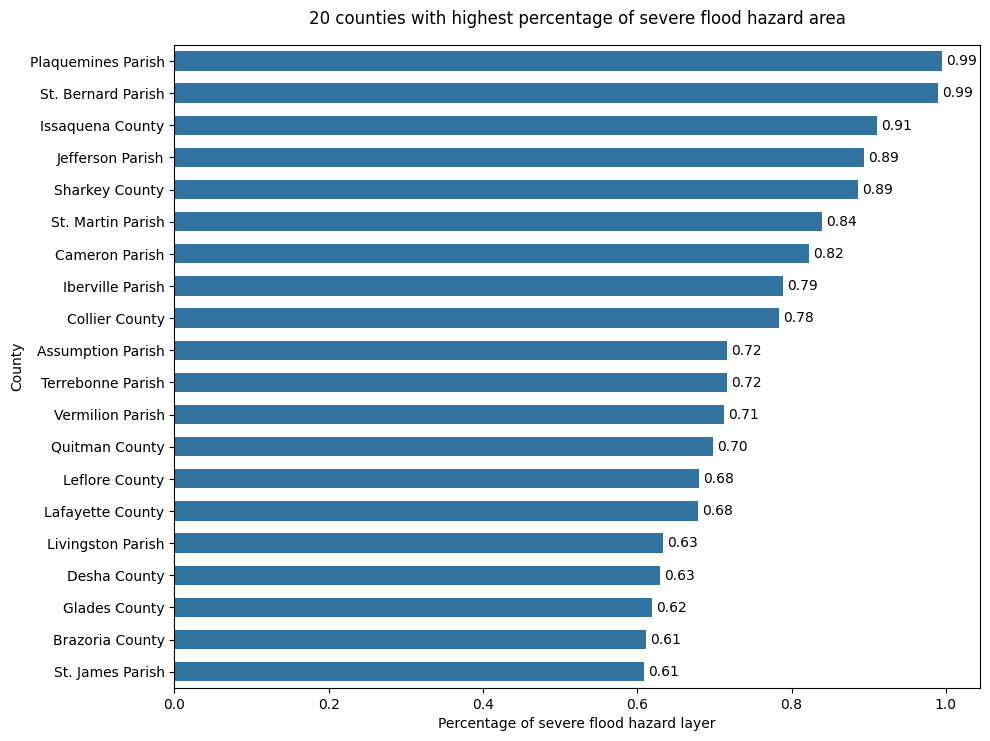

In [56]:
plt.figure(figsize = (10, 7.5))

ax = sns.barplot(
    data = flood_counties.nlargest(20, "pct_sfha"),
    y = "county_name",
    x = "pct_sfha",
    width = 0.6
)

for container in ax.containers:
  ax.bar_label(container, padding = 3, fmt = f"%.2f")

plt.xlabel("Percentage of severe flood hazard layer")
plt.ylabel("County")
plt.title("20 counties with highest percentage of severe flood hazard area", y = 1.02)
plt.tight_layout()

In [ ]:
flood_counties.to_csv("../data/processed_data/flood_by_counties.csv")